# ESERCITAZIONE 5

In [2652]:
import numpy as np
from scipy.special import factorial
import math
import matplotlib.pyplot as plt

In [2653]:
def Erlang_pdf(t, k, lam):
        return (lam**k * t**(k-1) * np.exp(-lam*t)) / math.factorial(k-1)

In [2654]:
def Poisson_pdf(lam, k):
    return (lam**k / factorial(k)) * np.exp(-lam)

In [2655]:
def log_likelihood_binned(n, centri, lam):
    return np.sum(n * np.log(Erlang_pdf(centri, 2, lam)))

In [2656]:
def log_likelihood_binned2(n, k, lam):
    return np.sum(n * np.log(Poisson_pdf(lam, k)))

In [2657]:
def chi_squared_binned2(n, N, lam, k, delta_x):
    return np.sum((n - delta_x*N*Poisson_pdf(lam,k))**2 / n)

In [2658]:
def chi_squared_binned(n, centri, N, lam, delta_x):
    return np.sum((n - delta_x*N*Erlang_pdf(centri, 2, lam))**2 / n)

In [2659]:
dati = np.loadtxt("dati/gruppo1.txt")
dati = dati/1000
#valori di indici pari
pari = dati[::2]
#valori di indici dispari
dispari = dati[1::2]
#sommo i dispari ai pari
#nel caso l'array dei pari sia più lungo di quello dei dipari ignoro l'ultimo pari
if(len(pari)>len(dispari)):
    pari = pari[:-1]
risultato = pari+dispari

lam=1/3.3486          

[ 54 120 172 211 212 213 216 244 249 239 232 245 186 206 203 189 169 153
 173 143 119 118  93 104  84  79  81  73  73  58  58  42  35  29  44  28
  31  11  15  14  22  16  15  12  10   5   7   9   7   9   4   4   3   4
   1   1   0   4   1   2   0   2   2   1   2   4   0   2   2   0   0   0
   0   0   1   2   0   1   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   1]


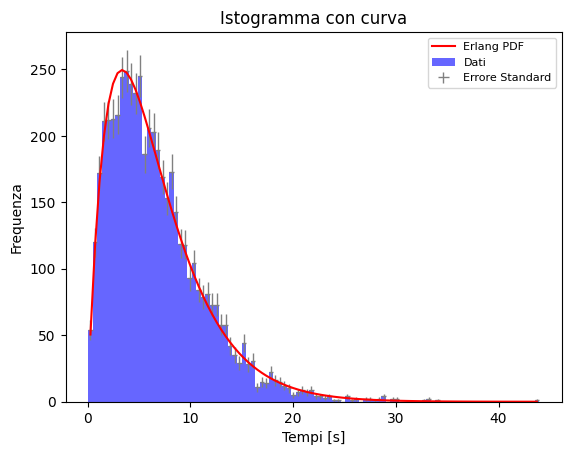

In [2660]:
h, bin_edges = np.histogram(risultato, bins=100)
delta_x = bin_edges[1] - bin_edges[0]
centri = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(centri, h, width=delta_x, color='blue',  alpha=0.6, label='Dati')
plt.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2, fmt='none', color='grey', lw=1, label='Errore Standard')
plt.plot(centri, Erlang_pdf(centri, 2, lam) *len(risultato)*delta_x ,color='red', label='Erlang PDF')
plt.legend(fontsize=8)
plt.xlabel('Tempi [s]')
plt.ylabel('Frequenza')
plt.title(f'Istogramma con curva')
print(h)

In [2661]:
var_lam = (1/(3.346)**4) * 0.001083473949988824
valori_lam = np.linspace(lam-3*np.sqrt(var_lam), lam + 3*np.sqrt(var_lam), 1000)
val_log_likelihood = [log_likelihood_binned(h, centri, lam) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_log_likelihood[i] > val_log_likelihood[i+1]:
        print(f"Massimo log-likelihood: {valori_lam[i]:.4f} con valore: {val_log_likelihood[i]:.4f}")
        max_log_likelihood = valori_lam[i]
        valore_max = val_log_likelihood[i]
        break
    else:
        continue

Massimo log-likelihood: 0.2987 con valore: -14402.8735


In [2662]:
valori_lam_mezzo = []

likelihood_val = valore_max - 0.5
tolleranza = 0.01

for i in range(len(valori_lam)):
    if abs(val_log_likelihood[i] - likelihood_val) < tolleranza:
        print(f"valore vicino a log_likelihood -1/2: {valori_lam[i]:.4f}")
        valori_lam_mezzo.append(valori_lam[i])
        
    if len(valori_lam_mezzo) == 5:
        break

print(f"Valori di lambda trovati: {[f'{x:.4f}' for x in valori_lam_mezzo]}")

valore vicino a log_likelihood -1/2: 0.2957
valore vicino a log_likelihood -1/2: 0.2957
valore vicino a log_likelihood -1/2: 0.2957
valore vicino a log_likelihood -1/2: 0.3016
valore vicino a log_likelihood -1/2: 0.3016
Valori di lambda trovati: ['0.2957', '0.2957', '0.2957', '0.3016', '0.3016']


Sigma di lambda: -0.0030


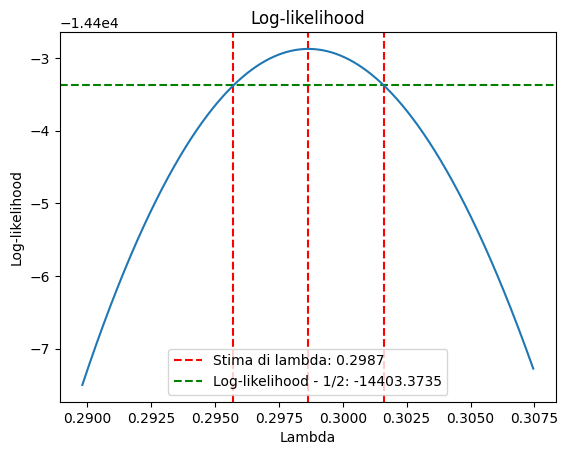

In [2663]:
plt.axvline(max_log_likelihood, color='red', linestyle='--', label=f'Stima di lambda: {max_log_likelihood:.4f}')
plt.axvline(0.2957, color='red', linestyle='--')
plt.axvline(0.3016, color='red', linestyle='--')
plt.axhline(valore_max - 0.5, color='green', linestyle='--', label=f'Log-likelihood - 1/2: {valore_max - 0.5:.4f}')
plt.plot(valori_lam, val_log_likelihood)
plt.title("Log-likelihood")
plt.xlabel("Lambda")
plt.ylabel("Log-likelihood")
plt.legend()
sigma_lam = 0.2957 - max_log_likelihood
print(f"Sigma di lambda: {sigma_lam:.4f}")

In [2664]:
h1 = h[:54]
print(h1)
centri1 = centri[:54]
val_chi_squared = [chi_squared_binned(h1, centri1, len(risultato), lam, delta_x) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_chi_squared[i] < val_chi_squared[i+1]:
        print(f"Minimo chi-squared: {valori_lam[i]:.4f} con valore: {val_chi_squared[i]:.4f}")
        min_chi_squared = valori_lam[i]
        valore_min = val_chi_squared[i]
        break
    else:
        continue

[ 54 120 172 211 212 213 216 244 249 239 232 245 186 206 203 189 169 153
 173 143 119 118  93 104  84  79  81  73  73  58  58  42  35  29  44  28
  31  11  15  14  22  16  15  12  10   5   7   9   7   9   4   4   3   4]
Minimo chi-squared: 0.3013 con valore: 67.4909


In [2665]:
valori_chi_uno = []

chi_val = valore_min + 1
tolleranza = 0.02

for i in range(len(valori_lam)):
    if abs(val_chi_squared[i] - chi_val) < tolleranza:
        print(f"valore vicino a chi-squared +1: {valori_lam[i]:.4f}")
        valori_chi_uno.append(valori_lam[i])
        
    if len(valori_chi_uno) == 5:
        break

print(f"Valori di chi-squared trovati: {[f'{x:.4f}' for x in valori_chi_uno]}")

valore vicino a chi-squared +1: 0.2983
valore vicino a chi-squared +1: 0.2984
valore vicino a chi-squared +1: 0.2984
valore vicino a chi-squared +1: 0.3043
valore vicino a chi-squared +1: 0.3043
Valori di chi-squared trovati: ['0.2983', '0.2984', '0.2984', '0.3043', '0.3043']


Sigma di lambda: -0.0029


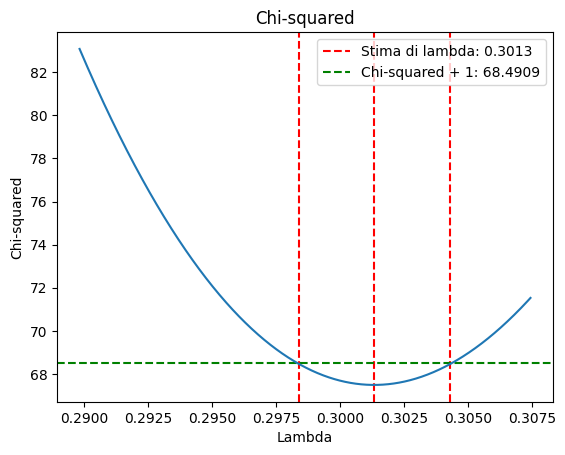

In [2666]:
plt.axvline(min_chi_squared, color='red', linestyle='--', label=f'Stima di lambda: {min_chi_squared:.4f}')
plt.axvline(0.2984, color='red', linestyle='--')
plt.axvline(0.3043, color='red', linestyle='--')
plt.axhline(valore_min + 1, color='green', linestyle='--', label=f'Chi-squared + 1: {valore_min + 1:.4f}')
plt.plot(valori_lam, val_chi_squared)
plt.title("Chi-squared")
plt.xlabel("Lambda")
plt.ylabel("Chi-squared")
plt.legend()
sigma_lam = 0.2984 - min_chi_squared
print(f"Sigma di lambda: {sigma_lam:.4f}")

In [2667]:
red = valore_min / (len(h1)-2)
print(f"Reduzione di chi-squared per punto: {red:.4f}")

Reduzione di chi-squared per punto: 1.2979


# SECONDA PARTE

In [2668]:
delta_t = 30
lam=lam*30

tcum = np.cumsum(dati)
tmin = 0
tmax = tcum[-1]

print(f"totale tempo trascorso {tmax}")

#creo un vettore di finestre a passi di delta_t che userò come tempo di inizio delle mie finestre temporali
w = np.arange(tmin,tmax,delta_t)
print(f"Tempo di inizio delle finestre temporali che userò: {w}")

#controllo se l'ultima finestra temporale è stata conclusa:
if (tmax<w[-1]+delta_t):
    print("Tolgo l'ultima finestra")
    w = w[:-1]

#faccio un loop sulle finestre
Poisson_counts = []

for i in w:
    #verifico se in ogni finestra ho conteggi 
    ind = np.where((tcum>=i) & (tcum<=(i+delta_t)))
    Poisson_counts.append(len(tcum[ind]))

print(f"\nI conteggi della mia Poisson sono {len(Poisson_counts)}")    

totale tempo trascorso 34654.2750000001
Tempo di inizio delle finestre temporali che userò: [0.000e+00 3.000e+01 6.000e+01 ... 3.459e+04 3.462e+04 3.465e+04]
Tolgo l'ultima finestra

I conteggi della mia Poisson sono 1155


[  2   4  15  40  73 115 138 153 138 132 127  80  55  34  24   7   7   5
   4   1]


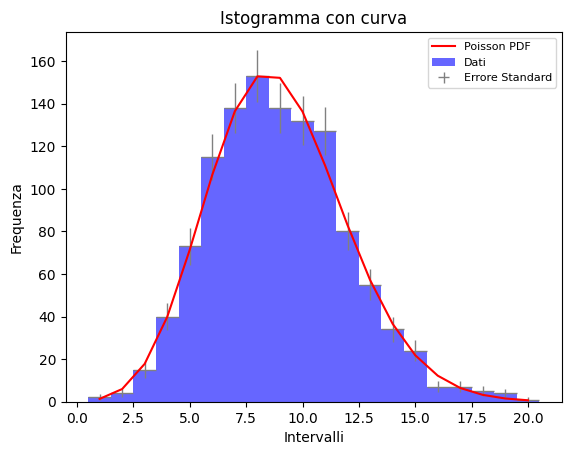

In [2669]:
h, bin_edges = np.histogram(Poisson_counts, bins=20, range=(0.5,20.5))
delta_x = bin_edges[1] - bin_edges[0]
centri = (bin_edges[:-1] + bin_edges[1:]) / 2
plt.bar(centri, h, width=delta_x, color='blue',  alpha=0.6, label='Dati')
plt.errorbar(centri, h, yerr=np.sqrt(h), xerr=delta_x/2, fmt='none', color='grey', lw=1, label='Errore Standard')
plt.plot(centri, Poisson_pdf(lam, centri) *len(Poisson_counts)*delta_x ,color='red', label='Poisson PDF')
plt.legend(fontsize=8)
plt.xlabel('Intervalli')
plt.ylabel('Frequenza')
plt.title(f'Istogramma con curva')
print(h)

In [2670]:
sigma_lam = np.sqrt(var_lam) * 30
valori_lam = np.linspace(lam-3*sigma_lam, lam + 3*sigma_lam, 1000)
val_log_likelihood = [log_likelihood_binned2(h, centri, lam) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_log_likelihood[i] > val_log_likelihood[i+1]:
        print(f"Massimo log-likelihood: {valori_lam[i]:.4f} con valore: {val_log_likelihood[i]:.4f}")
        max_log_likelihood = valori_lam[i]
        valore_max = val_log_likelihood[i]
        break
    else:
        continue

Massimo log-likelihood: 8.9661 con valore: -2892.6613


In [2671]:
valori_lam_mezzo = []

likelihood_val = valore_max - 0.5
tolleranza = 0.01

for i in range(len(valori_lam)):
    if abs(val_log_likelihood[i] - likelihood_val) < tolleranza:
        print(f"valore vicino a log_likelihood -1/2: {valori_lam[i]:.4f}")
        valori_lam_mezzo.append(valori_lam[i])
        
    if len(valori_lam_mezzo) == 5:
        break

print(f"Valori di lambda trovati: {[f'{x:.4f}' for x in valori_lam_mezzo]}")

valore vicino a log_likelihood -1/2: 8.8777
valore vicino a log_likelihood -1/2: 8.8782
valore vicino a log_likelihood -1/2: 8.8787
valore vicino a log_likelihood -1/2: 9.0541
valore vicino a log_likelihood -1/2: 9.0546
Valori di lambda trovati: ['8.8777', '8.8782', '8.8787', '9.0541', '9.0546']


Sigma di lambda: 0.0959


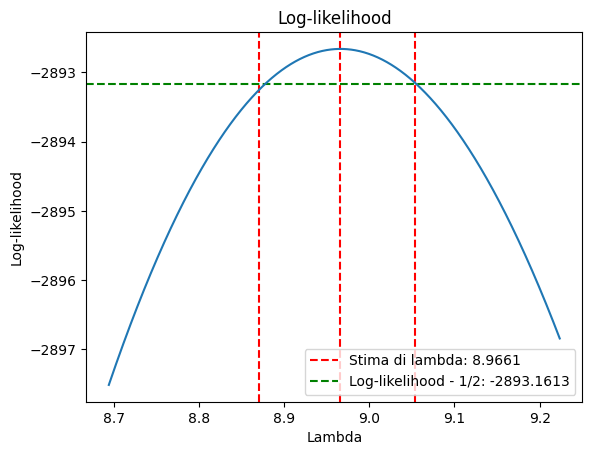

In [2672]:
plt.axvline(max_log_likelihood, color='red', linestyle='--', label=f'Stima di lambda: {max_log_likelihood:.4f}')
plt.axvline(8.8702, color='red', linestyle='--')
plt.axvline(9.0541, color='red', linestyle='--')
plt.axhline(valore_max - 0.5, color='green', linestyle='--', label=f'Log-likelihood - 1/2: {valore_max - 0.5:.4f}')
plt.plot(valori_lam, val_log_likelihood)
plt.title("Log-likelihood")
plt.xlabel("Lambda")
plt.ylabel("Log-likelihood")
plt.legend()

sigma_lam = max_log_likelihood - 8.8702
print(f"Sigma di lambda: {sigma_lam:.4f}")

In [2673]:
val_chi_squared = [chi_squared_binned2(h, len(Poisson_counts), lam, centri, delta_x) for lam in valori_lam]

for i in range(len(valori_lam)):
    if val_chi_squared[i] < val_chi_squared[i+1]:
        print(f"Minimo chi-squared: {valori_lam[i]:.4f} con valore: {val_chi_squared[i]:.4f}")
        min_chi_squared = valori_lam[i]
        valore_min = val_chi_squared[i]
        break
    else:
        continue

Minimo chi-squared: 8.9333 con valore: 12.6933


In [2674]:
valori_chi_uno = []

chi_val = valore_min + 1
tolleranza = 0.02

for i in range(len(valori_lam)):
    if abs(val_chi_squared[i] - chi_val) < tolleranza:
        print(f"valore vicino a chi-squared +1: {valori_lam[i]:.4f}")
        valori_chi_uno.append(valori_lam[i])
        
    if len(valori_chi_uno) == 5:
        break

print(f"Valori di chi-squared trovati: {[f'{x:.4f}' for x in valori_chi_uno]}")

valore vicino a chi-squared +1: 8.8469
valore vicino a chi-squared +1: 8.8475
valore vicino a chi-squared +1: 8.8480
valore vicino a chi-squared +1: 9.0191
valore vicino a chi-squared +1: 9.0196
Valori di chi-squared trovati: ['8.8469', '8.8475', '8.8480', '9.0191', '9.0196']


Sigma di lambda: 0.0864


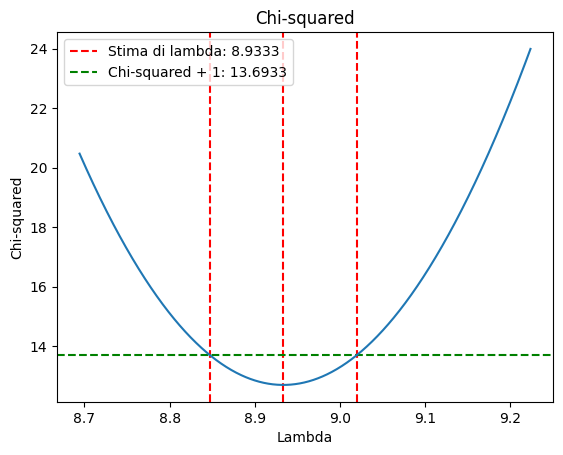

In [2675]:
plt.axvline(min_chi_squared, color='red', linestyle='--', label=f'Stima di lambda: {min_chi_squared:.4f}')
plt.axvline(8.8469, color='red', linestyle='--')
plt.axvline(9.0196, color='red', linestyle='--')
plt.axhline(valore_min + 1, color='green', linestyle='--', label=f'Chi-squared + 1: {valore_min + 1:.4f}')
plt.plot(valori_lam, val_chi_squared)
plt.title("Chi-squared")
plt.xlabel("Lambda")
plt.ylabel("Chi-squared")
plt.legend()
sigma_lam = min_chi_squared- 8.8469  
print(f"Sigma di lambda: {sigma_lam:.4f}")

In [2676]:
red = valore_min / (len(h)-2)
print(f"Chi-squared ridotto {red:.4f}")
red2=np.sqrt((2*valore_min)/(2*(len(h)-3)))
print(f"Chi-squared ridotto, corretto: {red2:.4f}")

Chi-squared ridotto 0.7052
Chi-squared ridotto, corretto: 0.8641


# TERZA PARTE

In [2677]:
t = np.array([0, 1, 2, 3, 4, 5, 6, 7, 8]) #tempo in ore
cont = np.array([997, 520, 265, 127, 70, 35, 16, 7, 3])
sigma_cont =1/ np.sqrt(cont)
ln_cont = np.log(cont)
print(ln_cont)

[6.90475077 6.25382881 5.57972983 4.84418709 4.24849524 3.55534806
 2.77258872 1.94591015 1.09861229]


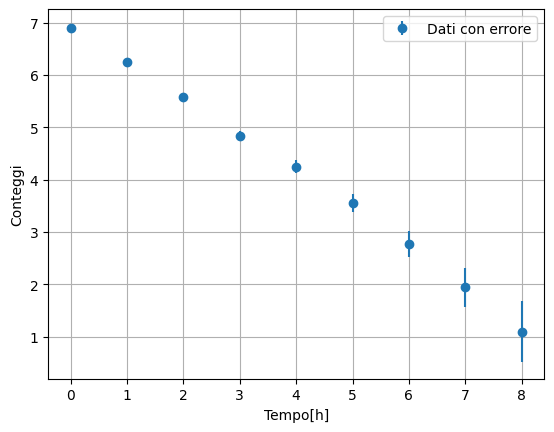

In [2678]:
plt.errorbar(t, ln_cont, yerr=sigma_cont, fmt='o', label='Dati con errore')
plt.xlabel('Tempo[h]')
plt.ylabel('Conteggi')
plt.legend()
plt.grid(True)
plt.show()

In [2679]:
N = len(t) #numero di componenti del vettore t
#per calcolare le sommatorie uso il metodo sum che calcola la somma di tutti gli elementi di un vettore
Wx = np.sum(t/(sigma_cont**2))  
Wy = np.sum(ln_cont/(sigma_cont**2))
Wxx = np.sum((t^2) / (sigma_cont**2))
Wxy = np.sum((t*ln_cont) / (sigma_cont**2))
W = np.sum(1/(sigma_cont**2))

den = W * Wxx - (Wx)**2
m = (W * Wxy - Wx * Wy) / den
q = (Wxx * Wy - Wx * Wxy) / den


var_m = W/den
var_q = Wxx/ den

print(f"stima di m: {m:.2f} ± {np.sqrt(var_m):.2f} [1/h], stima di q: {q:.2f} ± {np.sqrt(var_q):.2f} ")


stima di m: -1.06 ± 0.02 [1/h], stima di q: 7.30 ± 0.03 


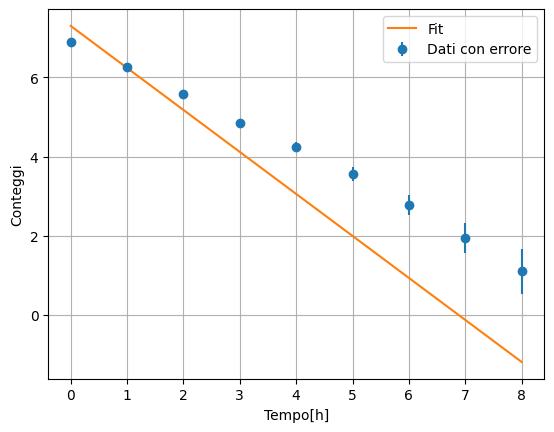

In [2680]:
#aggiungo la retta che ho stimato al grafico di prima
cont_fit = m * t + q
plt.errorbar(t, ln_cont, yerr=sigma_cont, fmt='o', label='Dati con errore')
plt.plot(t, cont_fit, label='Fit')
plt.xlabel('Tempo[h]')
plt.ylabel('Conteggi')
plt.legend()
plt.grid(True)
plt.show()

In [2681]:
tau_stim=-1/m
print(tau_stim)
print(tau_stim*60*60)
var_tau= (1/m**2) * np.sqrt(var_m)
print(f"stima di t: {tau_stim*60*60:.2f} ± {np.sqrt(var_tau)*60*60:.2f} [s]")

0.9423831635341029
3392.5793887227705
stima di t: 3392.58 ± 484.46 [s]
